# 第053讲 调参与实验预算

从纸笔账本走向真实CPU实验。先固定预算，再选择模型；测试标签不能进入搜索。下面所有输出都由当前内核实际生成。完整推导见lecture.pdf，逐项练习见lab.pdf。

## 1 确认输入
X每份600×10，前240行为开发，后360行为测试。这里只检查形状，不用测试分数制定搜索规则。ROOT必须为本讲目录。

In [1]:
from pathlib import Path
import json, numpy as np
import experiment as e
from IPython.display import display, Image
data = np.load(e.ROOT/'data/draws.npz')
print(e.ROOT.name, data['X0'].shape, data['y0'].shape)
print(json.loads((e.ROOT/'data/protocol.json').read_text()))

053 (600, 10) (600,)
{'seeds': [5300, 5301, 5302, 5303, 5304, 5305], 'n_development': 240, 'n_test': 360, 'folds': 3, 'fold_seed': 531, 'domain': [[2, 0.2], [2, 0.4], [2, 0.6], [2, 0.8], [2, 1.0], [4, 0.2], [4, 0.4], [4, 0.6], [4, 0.8], [4, 1.0], [6, 0.2], [6, 0.4], [6, 0.6], [6, 0.8], [6, 1.0], [8, 0.2], [8, 0.4], [8, 0.6], [8, 0.8], [8, 1.0], [None, 0.2], [None, 0.4], [None, 0.6], [None, 0.8], [None, 1.0]], 'grid': [[2, 0.4], [2, 1.0], [6, 0.4], [6, 1.0], [None, 0.4], [None, 1.0]], 'random_candidates': 6, 'halving_candidates': [12, 4, 1], 'halving_resources': [15, 30, 60], 'search_trees_per_method': 1080, 'final_refit_trees_per_method': 60, 'restart_each_stage': True, 'comparison': 'equal requested trees, not equal time/FLOPs', 'test_policy': 'Only after winner and all search records are fixed'}


## 2 先算预算
不是数fit调用就够了：每次拟合的树数不同。当前淘汰每轮从头拟合。

In [2]:
print('grid:', 6*60*3, 'halving:', (12*15+4*30+1*60)*3)
print('final refit per route:', 60)
print('counterfactual warm-start search:', (12*15+4*15+1*30)*3)

grid: 1080 halving: 1080
final refit per route: 60
counterfactual warm-start search: 810


## 3 重新运行三条路线
这格真正训练所有模型。负结果会完整保留，不读预制experiment-result.json。

In [3]:
result = e.run()
e.dump(result, e.ROOT/'outputs/notebook-result.json')
print(json.dumps(result['summary'], ensure_ascii=False, indent=2))

{
  "grid": {
    "test_mse": 3.209981874666447,
    "test_mse_sd": 0.5376119932009644,
    "total_search_seconds": 6.880351714009521,
    "search_trees_per_rep": 1080,
    "refit_trees_per_rep": 60
  },
  "random": {
    "test_mse": 3.2900784564709205,
    "test_mse_sd": 0.49017504174101706,
    "total_search_seconds": 6.516771788999904,
    "search_trees_per_rep": 1080,
    "refit_trees_per_rep": 60,
    "paired_difference_vs_grid": [
      -0.04318947332311751,
      0.2706657589952597,
      0.02293275648275106,
      0.13081240304198127,
      0.09935804562996431,
      0.0
    ],
    "worse_than_grid_count": 4
  },
  "halving": {
    "test_mse": 3.2191012859017847,
    "test_mse_sd": 0.5212444060713689,
    "total_search_seconds": 7.24236955899687,
    "search_trees_per_rep": 1080,
    "refit_trees_per_rep": 60,
    "paired_difference_vs_grid": [
      0.0207095769683594,
      0.14022398156835436,
      -0.20557513675465033,
      0.0,
      0.09935804562996431,
      0.0
    ],

## 4 手算一个候选的折损失
按照valid_ids对齐标签，再求平方误差平均。

In [4]:
s = next(z for z in result['runs'] if z['rep']==0 and z['method']=='grid')
values=[]
for row in s['fits']:
    if row['candidate']==0:
        values.append(float(np.mean((data['y0'][row['valid_ids']]-row['prediction'])**2)))
print('three folds', values, 'mean', sum(values)/3)

three folds [5.591720164198068, 5.215694604967952, 5.842719480304671] mean 5.550044749823564


## 5 检查幸存者与失败记录
候选编号是当前configurations的局部下标；失败演示单独记账。

In [5]:
s=next(z for z in result['runs'] if z['rep']==0 and z['method']=='halving')
for stage in s['stages']:
    print(stage)
print(result['failure_demo'])

{'resource': 15, 'ranking': [{'candidate': 1, 'mse': 3.3446438452700384}, {'candidate': 6, 'mse': 3.375290864377894}, {'candidate': 9, 'mse': 3.389364027347232}, {'candidate': 10, 'mse': 3.4742083664705192}, {'candidate': 0, 'mse': 3.5653029565752}, {'candidate': 11, 'mse': 3.7272407308412596}, {'candidate': 7, 'mse': 3.7649141839102236}, {'candidate': 4, 'mse': 3.845486257616791}, {'candidate': 2, 'mse': 4.578504150987302}, {'candidate': 5, 'mse': 5.10107039928111}, {'candidate': 8, 'mse': 5.1592804875634695}, {'candidate': 3, 'mse': 5.199939038967847}]}
{'resource': 30, 'ranking': [{'candidate': 6, 'mse': 3.2147149878891597}, {'candidate': 9, 'mse': 3.223367390577225}, {'candidate': 1, 'mse': 3.267277227174795}, {'candidate': 10, 'mse': 3.32088552120678}]}
{'resource': 60, 'ranking': [{'candidate': 6, 'mse': 3.0865712999994828}]}
{'rep': -1, 'method': 'failure_demo', 'stage': 0, 'candidate': 0, 'depth': 4, 'max_features': 0, 'resource': 15, 'train_ids': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9,

## 6 独立审计
重算522次损失与18个最终重拟合，检查预算、生存集合和测试标签干预。

In [6]:
import audit
checks=audit.audit(result)
e.dump(checks,e.ROOT/'outputs/notebook-audit.json')
print(checks)

{'status': 'passed', 'checked_search_predictions': 522, 'independent_final_refits': 18, 'checks': ['cost ledger', 'disjoint folds', 'stage survival', 'all MSE arithmetic', 'test-label intervention', 'separate failed attempt', 'MSE unequal shapes', 'MSE NaN', 'unknown method'], 'not_claimed': ['global optimum', 'equal wall-clock time', 'statistical superiority across real datasets']}


## 7 重建图
图从本次result产生。计时图允许随机器负载变化。后面每格显示一张实际重建图。

In [7]:
import plots
paths=plots.draw(result,e.ROOT/'outputs/notebook-figures')
print([p.name for p in paths])

['01_protocol.png', '02_search_space.png', '03_halving.png', '04_results.png', '05_costs.png', '06_selection_noise.png', '07_early_stop.png']


数据权限：没有测试到搜索的箭头。

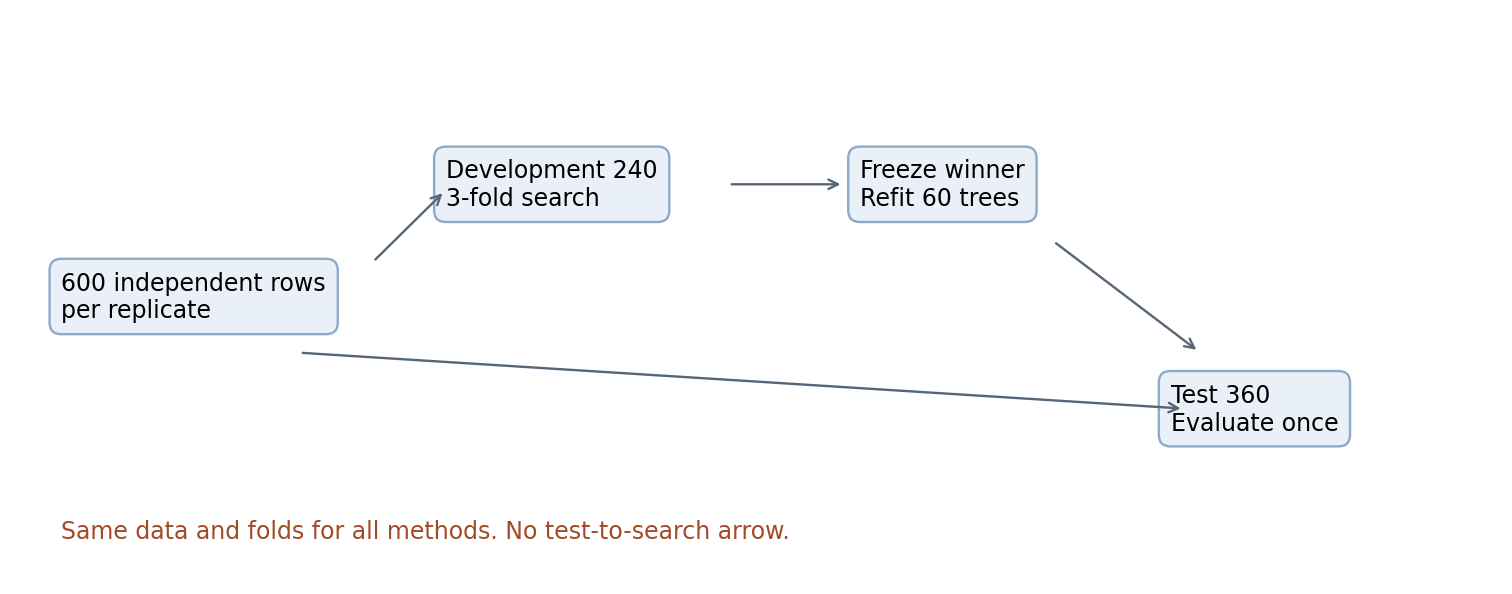

In [8]:
display(Image(filename=str(paths[0])))

同域不同候选政策，不等于实际点完全相同。

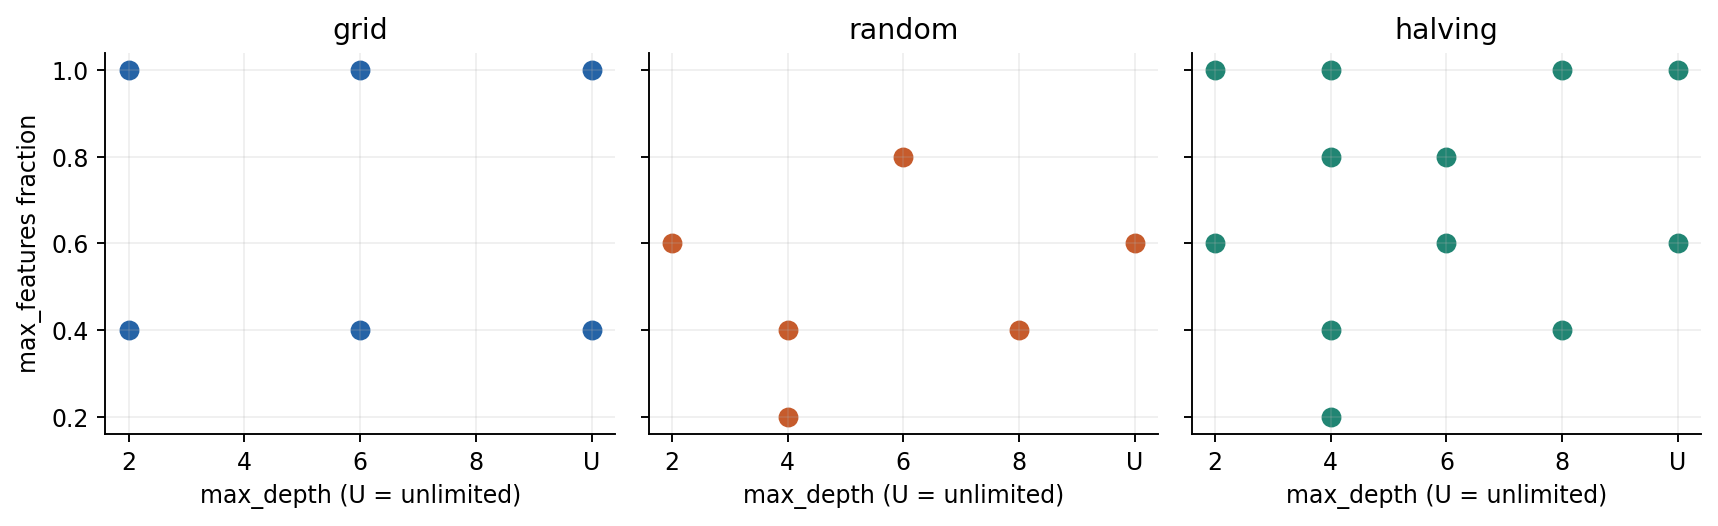

In [9]:
display(Image(filename=str(paths[1])))

淘汰候选的未来曲线是未知的。

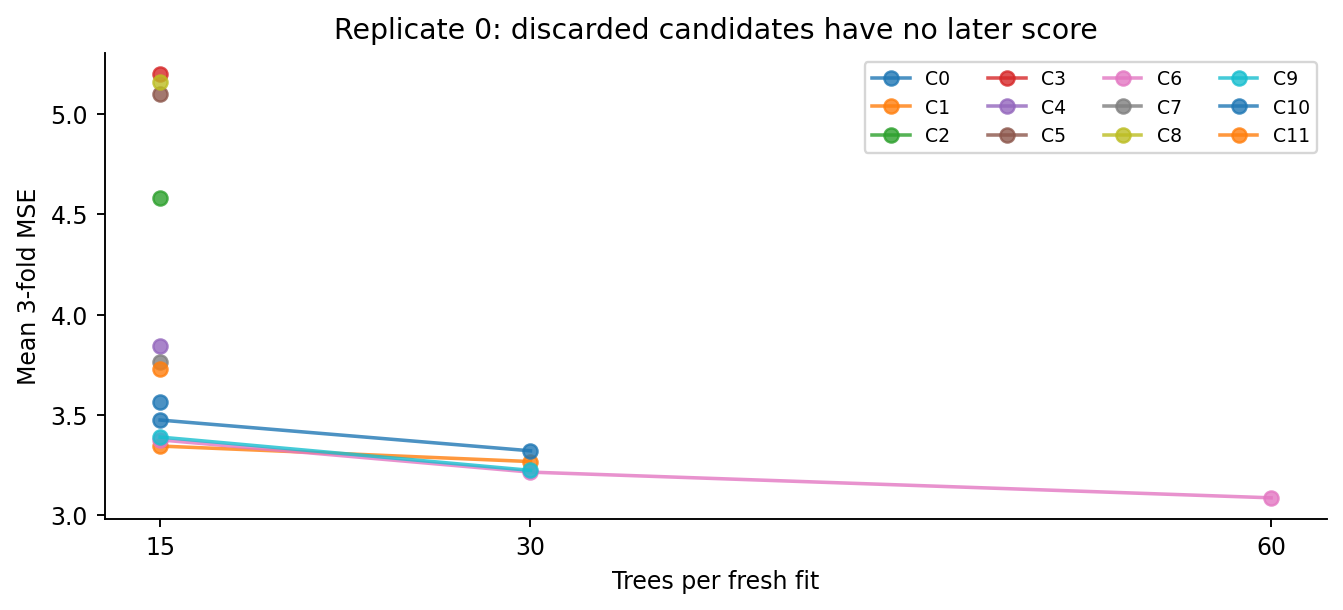

In [10]:
display(Image(filename=str(paths[2])))

所有独立份数与配对差都保留。

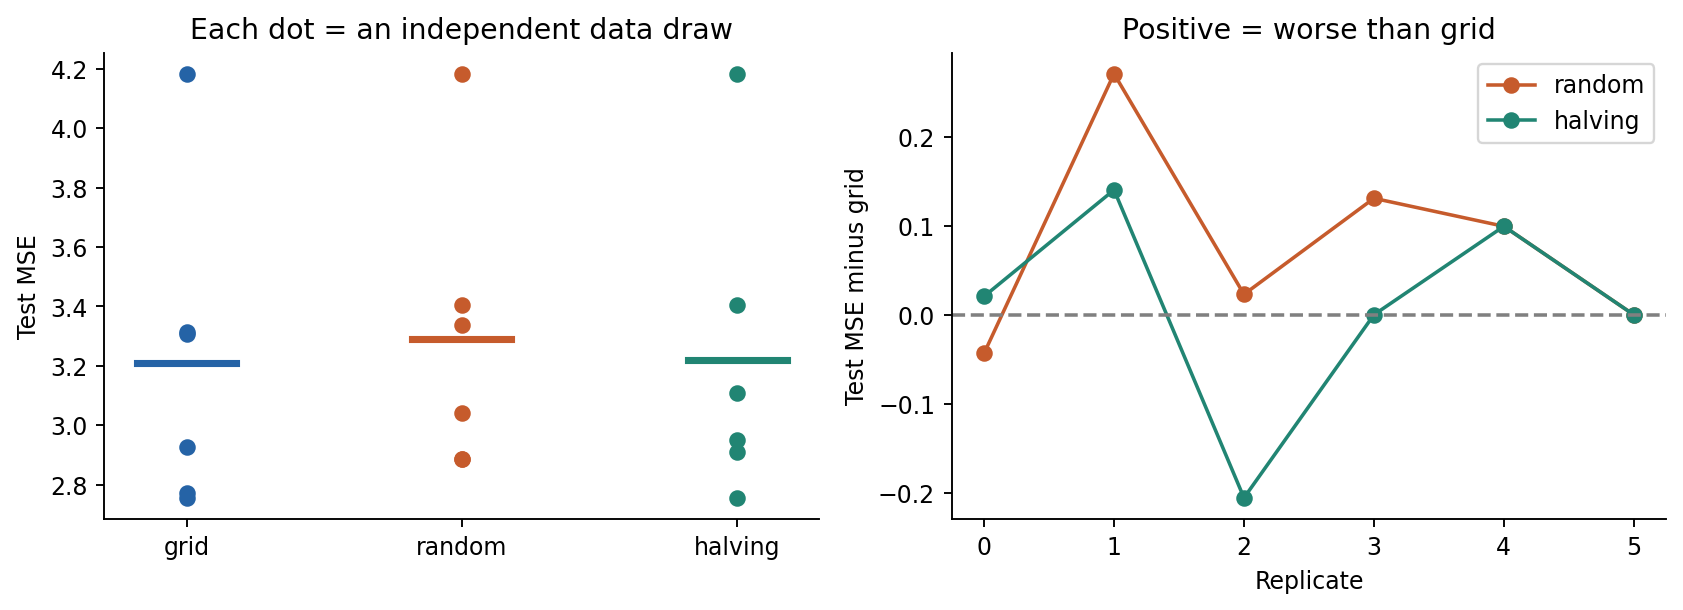

In [11]:
display(Image(filename=str(paths[3])))

同树数不等同时间。

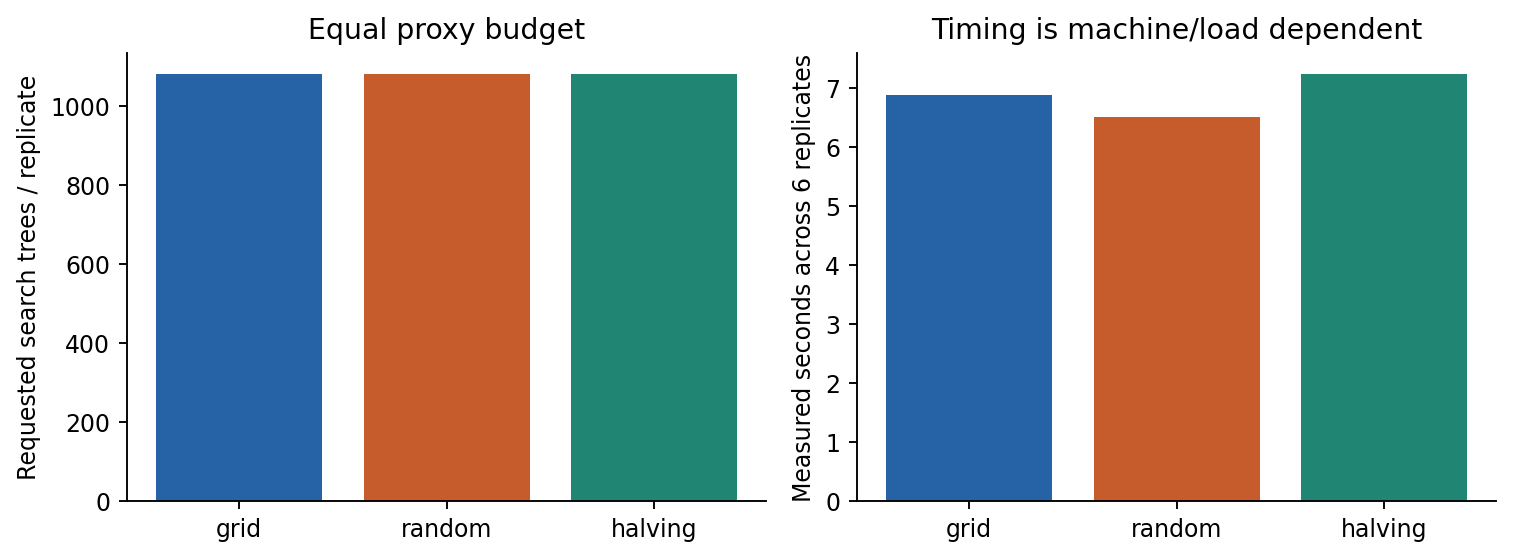

In [12]:
display(Image(filename=str(paths[4])))

人造选择噪声示意，非真实数据集胜率。

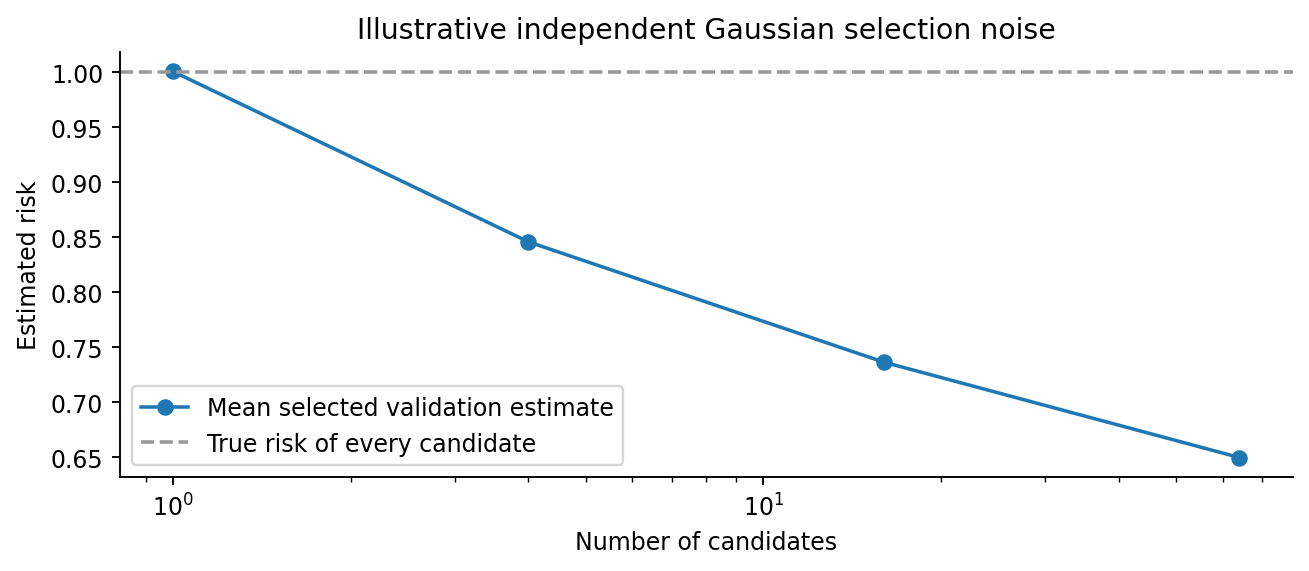

In [13]:
display(Image(filename=str(paths[5])))

构造慢热反例，非本次森林实測。

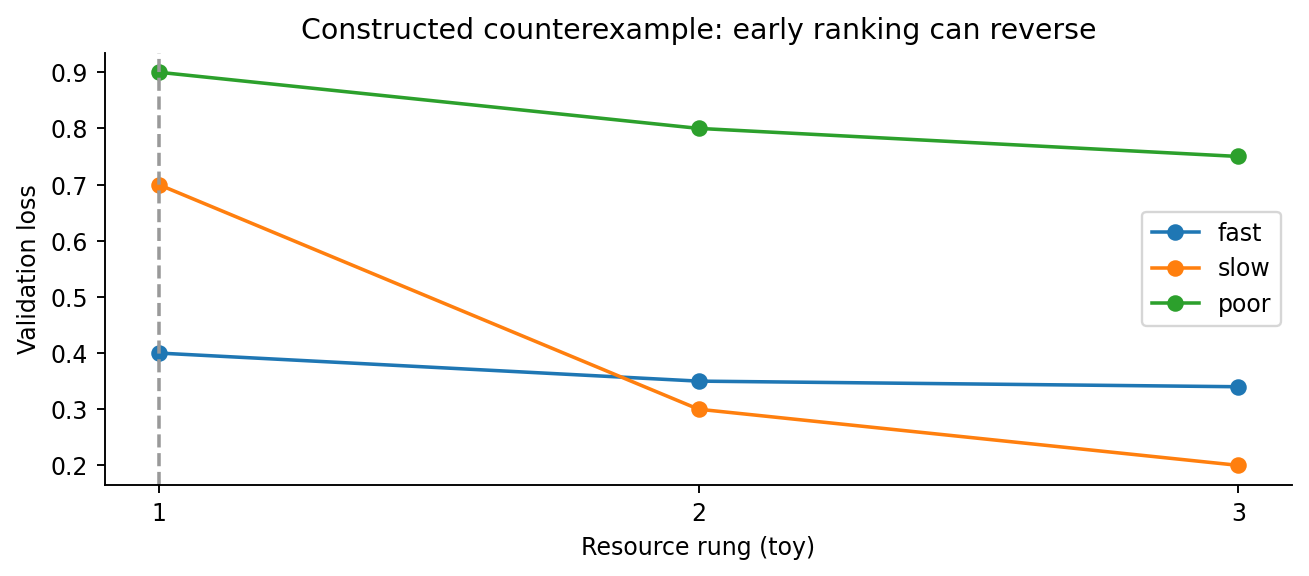

In [14]:
display(Image(filename=str(paths[6])))

## 8 自己写结论
为什么random四份更差仍是有效结果？为什么本实验没有Bayesian优化的实测排名？请回答后再读answers.pdf。来源见sources.md；三方法只在固定同一合成机制下比较。